# Worksheet: CNN Implementation

**Topic:** CNN Implementation, LeNet-5, and Pre-Trained Models

## Learning goals

By the end of this worksheet, students should be able to:

1. Load and preprocess image data for CNNs.
2. Build a LeNet-style CNN for CIFAR-10.
3. Train and evaluate a CNN classifier.
4. Interpret learning curves and predictions.
5. Explain padding, pooling, batch normalization, and data augmentation.
6. Use a pre-trained CNN for transfer learning.
7. Fine-tune a pre-trained model for a new image task.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


---

# 1. CNN implementation roadmap

In this notebook, we will work through two major implementation ideas:

1. **Train a CNN from scratch** on CIFAR-10 using a LeNet-style architecture  
2. **Use a pre-trained model** and adapt it through transfer learning

**Review:** Convolutions

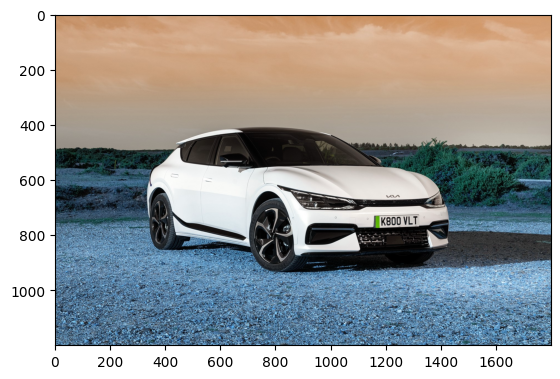

In [ ]:
import cv2

## read image
car_color = cv2.imread('car_image.jpeg')
car_gray = cv2.cvtColor(car_color, cv2.COLOR_BGR2GRAY)

## plot
plt.imshow(car_color)
plt.show()

In [ ]:
car_color.shape

(1200, 1800, 3)

In [ ]:
car_gray.shape

(1200, 1800)

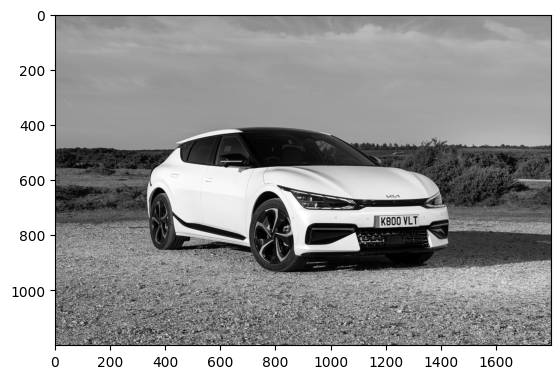

In [ ]:
## plot
plt.imshow(car_gray , cmap = "gray")
plt.show()

In [ ]:
## computes the whole convolution

def Convolution2D(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Extract the patch from the image
            patch = image[i:i + kernel_height, j:j + kernel_width]
            # Perform element-wise multiplication and sum
            output[i, j] = np.sum(patch * kernel)

    return output

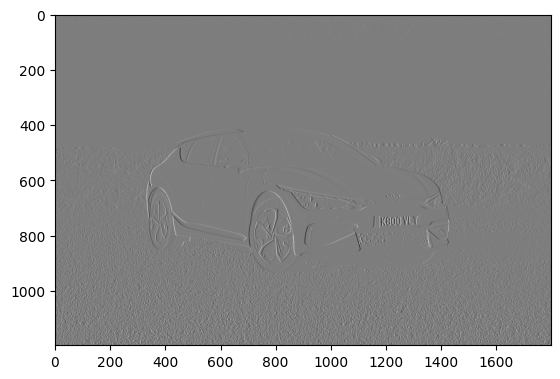

In [ ]:
## Edge Filter (Horizontal)
## corner capture
edge_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

## Apply Edge Filter and Plot
## what is the resulting feature map size?
## rows: 1200 - 3 + 1: 1198 pixels rows
## cols: 1800 - 3 + 1: 1798 pixels cols


car_filterh = Convolution2D(car_gray, edge_kernel)
plt.imshow(car_filterh, cmap = "gray")
plt.show()

In [ ]:
car_filterh.shape

(1198, 1798)

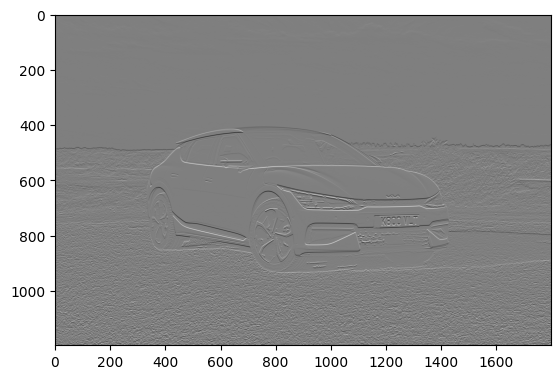

In [ ]:
## Edge Filter (Vertical)
edgev_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

## Apply Edge Filter and Plot

car_filterv = Convolution2D(car_gray, edgev_kernel)
plt.imshow(car_filterv, cmap = "gray")
plt.show()

In a Convolution layer, each neuron will produce a different feature map. For each image, the convolution layer learns different representations of the same image.

Pooling

Pooling is used to downsample feature maps while keeping important information.

Common types:
- **Max pooling**
- **Average pooling**

In [ ]:
## 4x4 feature map
feature_map = np.array([
    [1, 3, 2, 0],
    [4, 6, 5, 1],
    [0, 2, 8, 7],
    [1, 3, 4, 2]
])

print(feature_map)

[[1 3 2 0]
 [4 6 5 1]
 [0 2 8 7]
 [1 3 4 2]]


In [ ]:
## MAXPOOLING

def max_pooling(image, pool_size=(2, 2), stride=1):
    map_height, map_width = image.shape
    pool_height, pool_width = pool_size

    output_height = (map_height - pool_height) // stride + 1
    output_width = (map_width - pool_width) // stride + 1

    pooled_output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # FIXED: Extract the pooling window from 'image', not 'feature_map'
            window = image[i * stride : i * stride + pool_height,
                           j * stride : j * stride + pool_width]
            # Apply max pooling
            pooled_output[i, j] = np.max(window)

    return pooled_output

In [ ]:
## Apply max pooling to feature map
pooled_output = max_pooling(feature_map)
print(pooled_output)

[[6. 6. 5.]
 [6. 8. 8.]
 [3. 8. 8.]]


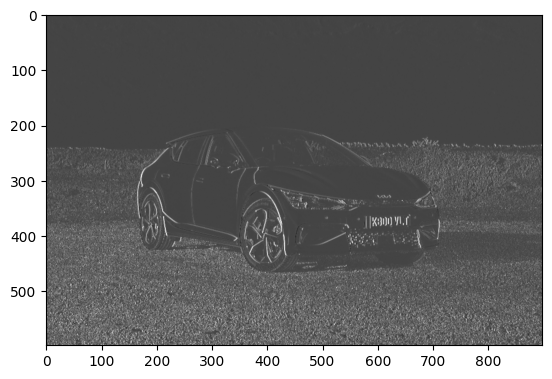

In [ ]:
## Apply max pooling to car filter
## let's apply to car_filterh

pooled_output = max_pooling(car_filterh, pool_size=(3, 3), stride=2)
plt.imshow(pooled_output, cmap = "gray")
plt.show()

In [ ]:
pooled_output.shape

## pooling layers reduce the size and keep the same structure of the image

(598, 898)

In [ ]:
## AVERAGE POOLING

def average_pooling(feature_map, pool_size=(2, 2), stride=1):
    map_height, map_width = feature_map.shape
    pool_height, pool_width = pool_size

    output_height = (map_height - pool_height) // stride + 1
    output_width = (map_width - pool_width) // stride + 1

    pooled_output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Extract the pooling window
            window = feature_map[i * stride : i * stride + pool_height,
                                   j * stride : j * stride + pool_width]
            # Apply average pooling
            pooled_output[i, j] = np.mean(window)

    return pooled_output

In [ ]:
## Apply avg pooling to feature map






In [ ]:
## Apply avg pooling to car filter







## Practice 1A: Concept check

In your own words, what is the main difference between:

1. training a CNN from scratch  
2. using a pre-trained CNN

**Your response here:**  
1.  Training from scratch involves learning the parameters of each kernel (convolutions), and also the regular feed-forward neurons. This takes a lot of computational power.
2.  You are going to import a pretrained model. Fix the kernel weight to NOT be trainable. Just train the feed-forward architecture.

---

# 2. CIFAR-10 dataset

CIFAR-10 is a standard image-classification dataset with:
- 10 classes
- 60,000 color images
- image size 32 × 32 × 3

This makes it a good dataset for practicing CNN implementation.

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Practice 2A: Load CIFAR-10

Load the training and test sets.

In [ ]:
# TODO
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


## Practice 2B: Explore the data

CIFAR-10 class labels are:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

In [ ]:

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Display the first 9 training images and their labels.

/tmp/ipykernel_560/3598362743.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


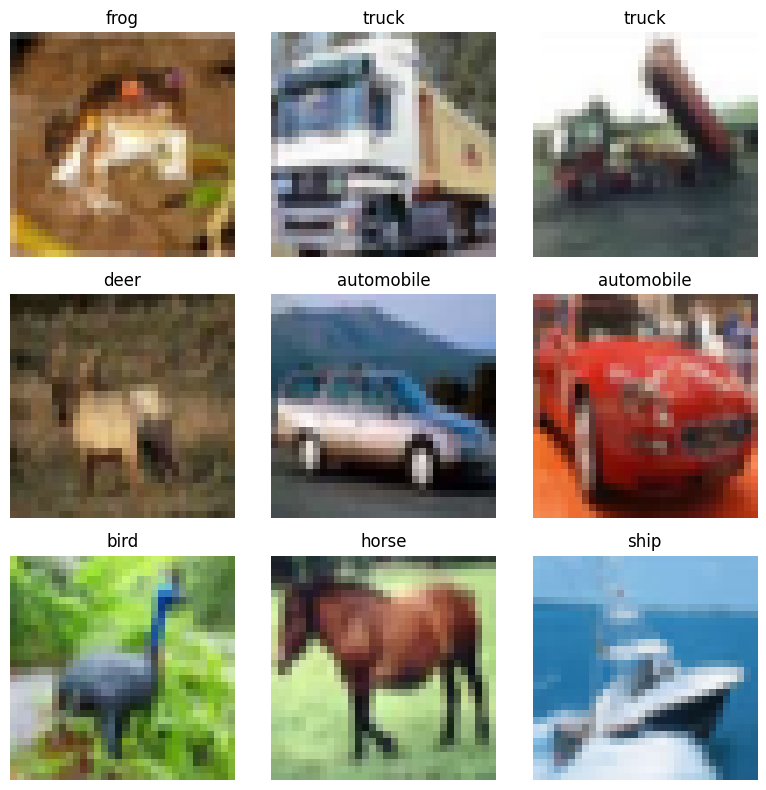

In [ ]:
# TODO
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for i in range(9):
     plt.subplot(3, 3, i+1)
     plt.imshow(x_train[i])
     plt.title(class_names[int(y_train[i])])
     plt.axis("off")
plt.tight_layout()
plt.show()

## Practice 2C: Preprocess the images

Complete the preprocessing steps:
- convert images to float (decimals)
- scale pixels to [0, 1]
- flatten the target array so it has shape `(n,)`

In [ ]:

# TODO
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()
print(x_train.shape, y_train.shape)


(50000, 32, 32, 3) (50000,)


---

# 3. LeNet-5 style CNN

LeNet-5 is a foundational CNN architecture. The original version was designed for grayscale handwritten digits, but we can adapt the idea to CIFAR-10.

A simple LeNet-style architecture for CIFAR-10 might use:

- Input: 32 × 32 × 3
- Conv layer
- Pooling
- Conv layer
- Pooling
- Flatten
- Dense
- Dense
- Output layer

## Practice 3A: Build a LeNet-style CNN

Build a CNN with this structure:

- input shape = `(32, 32, 3)`
- `Conv2D(6, (5,5), activation="relu", padding="same")`  ## 6 images (for each) of size (32,32,3)
- `AveragePooling2D(pool_size=(2,2))`
- `Conv2D(16, (5,5), activation="relu")`
- `AveragePooling2D(pool_size=(2,2))`
- `Flatten()`
- `Dense(120, activation="relu")`
- `Dense(84, activation="relu")`
- `Dense(10, activation="softmax")`

Compile with:
- optimizer = `"adam"`
- loss = `"sparse_categorical_crossentropy"`
- metrics = `["accuracy"]`

In [ ]:
## create architecture
cnn = Sequential()
cnn.add(Input(shape=(32, 32, 3)))
cnn.add(Conv2D(6, (5, 5), activation="relu", padding="same"))
cnn.add(AveragePooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(16, (5, 5), activation="relu"))
cnn.add(AveragePooling2D(pool_size=(2, 2)))
cnn.add(Flatten())
cnn.add(Dense(120, activation="relu"))
cnn.add(Dense(84, activation="relu"))
cnn.add(Dense(10, activation="softmax"))

## summary
cnn.summary()

## compile
cnn.compile(
     optimizer="adam",
     loss="sparse_categorical_crossentropy",
     metrics=["accuracy"]
)

## early stopping
es = EarlyStopping(patience=5, restore_best_weights=True)

## fit
history = cnn.fit(
     x_train, y_train,
     validation_split=0.1,
     batch_size=64,
     epochs=40,
     callbacks=[es]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.3894 - loss: 1.6778 - val_accuracy: 0.4594 - val_loss: 1.4851
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4981 - loss: 1.3951 - val_accuracy: 0.5212 - val_loss: 1.3147
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5357 - loss: 1.2860 - val_accuracy: 0.5514 - val_loss: 1.2710
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5660 - loss: 1.2142 - val_accuracy: 0.5856 - val_loss: 1.1803
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5899 - loss: 1.1506 - val_accuracy: 0.5662 - val_loss: 1.2061
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6092 - loss: 1.0991 - val_accuracy: 0.5888 - val_loss: 1.1539
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6246 - loss: 1.0581 - val_accuracy: 0.6070 - val_loss: 1.1199
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6382 - loss: 1.0161 - val_accuracy: 

We are training the whole network from scratch. Pretrained would use all convolutional layers as Non-Trainable.

---

# 4. Train the LeNet-style CNN

## Practice 4A: Train the model

Train for a small number of epochs, such as:
- epochs = 5
- batch_size = 64
- validation_split = 0.1

You may add early stopping if you like.

## Practice 4B: Plot the learning curves

Plot:
- training accuracy
- validation accuracy

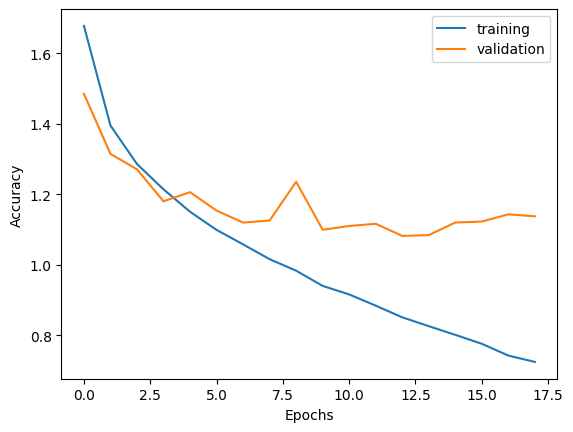

In [ ]:
## plot learning curve
plt.plot(history.history["loss"], label="training")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Practice 4C: Evaluate the model

Evaluate the model on the test set.

In [ ]:
## evaluate and performance
cnn.evaluate(x_test, y_test)

## confusion matrix
from sklearn.metrics import confusion_matrix

import numpy as np
preds = cnn.predict(x_test)
pred_labels = np.argmax(preds, axis=1)
cm = confusion_matrix(y_test, pred_labels)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6118 - loss: 1.1147
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[592  34  70  27  36  24  18  16 132  51]
 [ 18 774   8  10   3   8  11   7  49 112]
 [ 38   7 400 110 171 103  77  49  30  15]
 [ 12  12  55 452  94 240  64  30  20  21]
 [ 17  12  74  68 592  83  68  63  18   5]
 [ 10   5  52 193  68 579  34  42  10   7]
 [  5  11  37 104  68  44 694  15  11  11]
 [ 12  11  29  64  94 114  14 642   7  13]
 [ 43  63  14  21  25   6   6   7 781  34]
 [ 31 156  20  44  14  20  13  25  65 612]]


## Practice 4D: Look at predictions

Display 9 test images with:
- true label
- predicted label

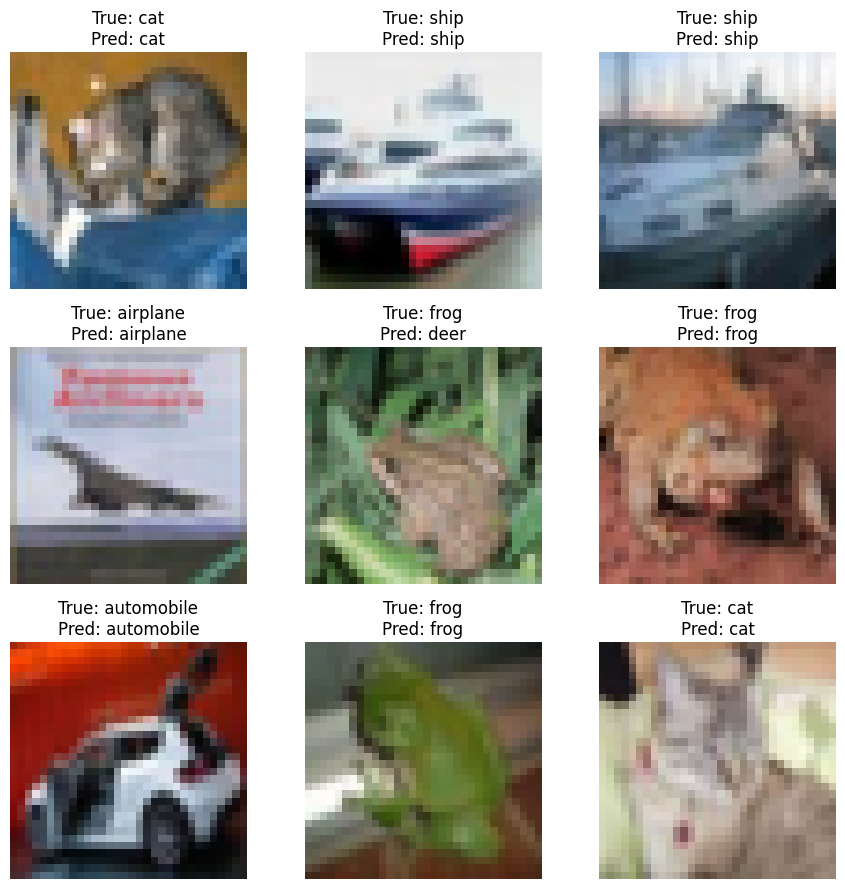

In [ ]:


preds = cnn.predict(x_test[:9], verbose=0)
pred_labels = np.argmax(preds, axis=1)
plt.figure(figsize=(9, 9))
for i in range(9):
     plt.subplot(3, 3, i+1)
     plt.imshow(x_test[i])
     plt.title(f"True: {class_names[y_test[i]]}\nPred: {class_names[pred_labels[i]]}")
     plt.axis("off")
plt.tight_layout()
plt.show()


---

# 5. Improving CNN training

The lecture materials highlight several practical tools used in CNN implementations:
- padding
- batch normalization
- data augmentation
- deeper architectures

## Practice 5A: Batch normalization

Why might batch normalization help CNN training?

**Your response here:**  


Batch normalization is helpful in preventing overfitting. After each convolutional layer batch normalization makes the weights (filter) to have a mean of zero and unit variance (variance = 1). It prevent large weights to dominate. Helps with training speed.

## Practice 5B: Data augmentation

What are some common image augmentation techniques?

**Your response here:**  

Data augmentation increases the size of the data set, and the diversity of the images.

- cropping, resizing
- rotation
- add noise

This works at the batch level. E.g., batch = 16 (augmentation generates 16 images that are augmented to help training)

## Practice 5C: Add batch normalization

Modify the LeNet-style model so that batch normalization is applied after each convolution.

## Practice 5D: Add data augmentation

Create an `ImageDataGenerator` with a few augmentations, such as:
- horizontal flip
- small rotation
- width shift
- height shift

In [2]:
## unzip the file
import zipfile
import os

zip_path = '/content/cnn_project_damaged_vs_normal_package.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
## import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Define train/validation folders (ImageDataGenerator )
train_dir = '/content/cnn_project/data/train'
val_dir = '/content/cnn_project/data/val'

In [4]:
## Data augmentation
## we create a function to generate the images, e.g., train_datagen
train_datagen = ImageDataGenerator(
     rescale=1./255,
     horizontal_flip=True,
     rotation_range=15,
     width_shift_range=0.1,
     height_shift_range=0.1)

In [5]:
## create a val data generator but not changing the images
val_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
## Create instances of the generators
train_generator = train_datagen.flow_from_directory(
     train_dir,
     target_size=(32, 32),
     batch_size=16,
     class_mode='binary')

val_generator = val_datagen.flow_from_directory(
     val_dir,
     target_size=(32, 32),
     batch_size=16,
     class_mode='binary',
     shuffle = False)

Found 80 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [8]:
## Build a LeNet-style CNN
lenet = Sequential()
lenet.add(Input(shape=(32, 32, 3)))

## convolutional part
lenet.add(Conv2D(6, (5, 5), activation="relu", padding="same"))
lenet.add(BatchNormalization())
lenet.add(AveragePooling2D(pool_size=(2, 2)))

lenet.add(Conv2D(16, (5, 5), activation="relu"))
lenet.add(BatchNormalization())
lenet.add(AveragePooling2D(pool_size=(2, 2)))

## feed-foward
lenet.add(Flatten())

lenet.add(Dense(120, activation="relu"))
lenet.add(Dropout(0.2))
lenet.add(Dense(84, activation="relu"))
lenet.add(Dropout(0.2))

lenet.add(Dense(1, activation="sigmoid"))

## summary
lenet.summary()

## compile
lenet.compile(
     optimizer="adam",
     loss="binary_crossentropy",
     metrics=["accuracy"]
)

## early stopping
es = EarlyStopping(patience=5, restore_best_weights=True)

## fit
history = lenet.fit(
     train_generator,
     validation_data=val_generator,
     epochs=40,
     callbacks=[es]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,449 (322.07 KB)

 Trainable params: 82,405 (321.89 KB)

 Non-trainable params: 44 (176.00 B)

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.5125 - loss: 0.7748 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4250 - loss: 0.8064 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4750 - loss: 0.7020 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5625 - loss: 0.6583 - val_accuracy: 0.5000 - val_loss: 0.6965
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7375 - loss: 0.5743 - val_accuracy: 0.5000 - val_loss: 0.7143
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6750 - loss: 0.6196 - val_accuracy: 0.5000 - val_loss: 0.7332
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8000 - loss: 0.4579 - val_accuracy: 0.5000 - val_loss: 0.7986


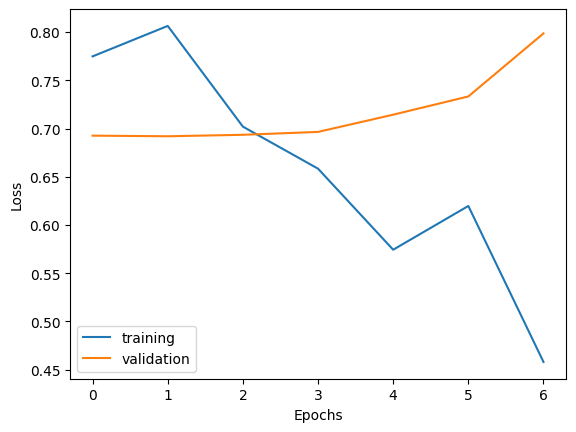

In [11]:
## plot learning curve
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="training")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


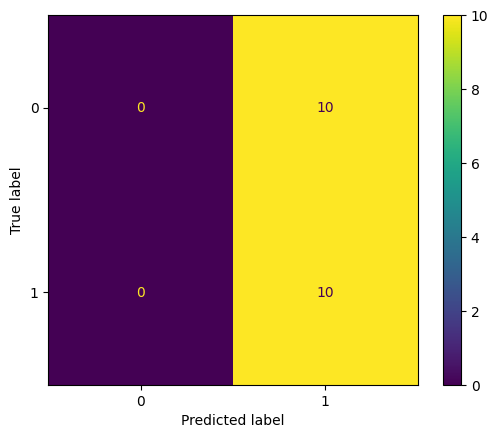

In [12]:
## Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
preds = lenet.predict(val_generator)
pred_labels = np.round(preds)
cm = confusion_matrix(val_generator.classes, pred_labels)
ConfusionMatrixDisplay(cm).plot()
plt.show()

---

# 6. Pre-trained models and transfer learning

In many practical image tasks, we do not train a CNN from scratch.

Instead, we:
1. start with a pre-trained model
2. remove or replace the original output layer
3. train a new classifier on top of the learned image features

This is called **transfer learning**.

## Practice 6A: Concept check

Why can pre-trained models be useful?

**Your response here:**  

We do not need to train the model for too long. We can use the weights (convolutions) of highly trained models even if it is not the same problem. Idea is to download convolutional part, so that we can fit the feed-forward part

## Practice 6B: Choose a pre-trained CNN

Common pre-trained models include:
- VGG16
- ResNet50
- MobileNetV2
- EfficientNet

For this worksheet, we will use **MobileNetV2** because it is relatively lightweight.

In [13]:
## we have to get the weigths from a github repo
## tensorflow has some pretrained models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2()
base_model.summary()

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

GlobalAveragePooling is similar to the flatten layer. It only retains the global average of each feature map. Prefered when we have too many layers.

---

# 7. Transfer learning with a pre-trained model

Pre-trained models are usually trained on ImageNet, which uses larger images such as 224 × 224.

So we need to resize CIFAR-10 images before feeding them into the model.

## Practice 7A: Resize images

Resize a small subset of CIFAR-10 images to `(224, 224)` and preprocess them for MobileNetV2.

In [14]:
## Load the pre-trained model (set the convolutional as part as non-trainable)
## include_top = False means do not include the feed-forward architecture
base_model = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights = 'imagenet')
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
## Data augmentation
## we create a function to generate the images, e.g., train_datagen
train_datagen = ImageDataGenerator(
     rescale=1./255,
     horizontal_flip=True,
     rotation_range=15,
     width_shift_range=0.1,
     height_shift_range=0.1)

In [16]:
## Create instances of the generators
train_generator = train_datagen.flow_from_directory(
     train_dir,
     target_size=(224, 224),
     batch_size=16,
     class_mode='binary')

val_generator = val_datagen.flow_from_directory(
     val_dir,
     target_size=(224, 224),
     batch_size=16,
     class_mode='binary',
     shuffle = False)

Found 80 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [20]:
## Build our feed-forward architecture
## first attached base_model -----  feed-forward
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
output = Dense(1, activation="sigmoid")(x)

In [22]:
## combine the models
transfer_model = Model(inputs=inputs, outputs=output)

## summary
transfer_model.summary()

## compile
transfer_model.compile(
     optimizer="adam",
     loss="binary_crossentropy",
     metrics=["accuracy"]
)

## early stopping
es = EarlyStopping(patience=5, restore_best_weights=True)

## fit
history = transfer_model.fit(
     train_generator,
     validation_data=val_generator,
     epochs=40,
     callbacks=[es]
)

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 550ms/step - accuracy: 0.8250 - loss: 0.5310 - val_accuracy: 0.8500 - val_loss: 0.5226
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 1.0000 - loss: 0.3620 - val_accuracy: 0.8000 - val_loss: 0.4303
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 1.0000 - loss: 0.2494 - val_accuracy: 0.9500 - val_loss: 0.3203
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 1.0000 - loss: 0.1995 - val_accuracy: 1.0000 - val_loss: 0.2409
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.9875 - loss: 0.1442 - val_accuracy: 1.0000 - val_loss: 0.1932
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 1.0000 - loss: 0.1244 - val_accuracy: 1.0000 - val_loss: 0.1683
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - accuracy: 1.0000 - loss: 0.0940 - val_accuracy: 1.0000 - val_loss: 0.1546
Epoch 8/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 1.0000 - loss: 0.0728 - val_accuracy: 1.0000 - val_loss:

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 856ms/step


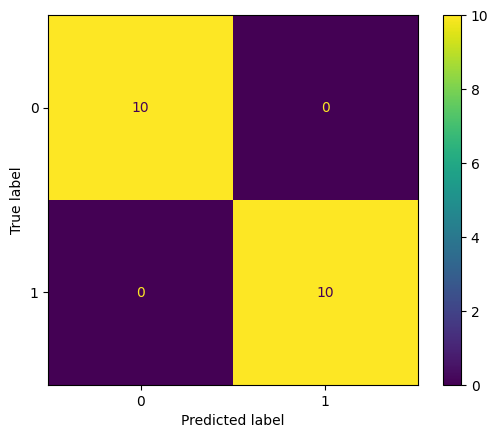

In [23]:
## Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
preds = transfer_model.predict(val_generator)
pred_labels = np.round(preds)
cm = confusion_matrix(val_generator.classes, pred_labels)
ConfusionMatrixDisplay(cm).plot()
plt.show()

## Practice 7E: Compare approaches

What are some tradeoffs between:
1. training LeNet-style CNN from scratch
2. using a pre-trained MobileNetV2 model

**Your response here:**  
1.  
2.

---

# 8. Optional fine-tuning

After transfer learning, a common next step is **fine-tuning**.

This means:
- unfreeze part of the pre-trained base model
- continue training with a small learning rate

## Practice 8B: Unfreeze some layers

Unfreeze the last portion of the base model and recompile with a smaller learning rate.

In [ ]:

# TODO
base_model.trainable = True

for layer in base_model.layers[:-20]:
     layer.trainable = False

 transfer_model.compile(
     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
     loss="sparse_categorical_crossentropy",
     metrics=["accuracy"])


---

# 9. Quiz-style review

Complete the following:

### Review 1
Why do we scale image pixel values before training?

### Review 2
Why is `softmax` used in the output layer for CIFAR-10?

### Review 3
What does batch normalization do?

### Review 4
What is data augmentation?

### Review 5
What is transfer learning?

### Review 6
Why do pre-trained models usually require resizing the images?

**Your responses here:**  
1.  
2.  
3.  
4.  
5.  
6.

## Quick self-check

Suggested answers:
- to keep inputs on a comparable numeric scale and help optimization
- because CIFAR-10 is a multi-class classification problem
- it normalizes intermediate activations and can stabilize training
- it increases training diversity by transforming images
- it reuses a model trained on another dataset
- because the pre-trained model expects a specific input size